Project Summary and Research Questions

This project examines how plant-based food markets and YouTube narratives developed across selected European countries from 2018 to 2020. It combines country-year-product sales data with YouTube video text data to compare market size, product-category composition, narrative prevalence, and the relationship between online narratives and plant-based food sales. Since sales value and volume are strongly correlated, the later analysis focuses mainly on Value EUR as the key market indicator. The YouTube analysis uses seven narrative dimensions: health, environment, animal welfare, food security, taste, price, and convenience. Positive and negative mentions are combined into one binary variable for each narrative dimension.

- Main RQ: How are YouTube narratives about plant-based foods associated with plant-based food sales patterns across selected European countries from 2018 to 2020?
- Sub-RQ1: How do plant-based food sales values vary across countries, years, and product groups?
- Sub-RQ2: How does the product-category composition of plant-based food sales differ across countries and over time?
- Sub-RQ3: Which YouTube narrative dimensions are most frequently mentioned across countries and years?
- Sub-RQ4: To what extent are the seven YouTube narrative dimensions associated with total plant-based food sales value at the country-year level?


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from analysis_helpers import (
    add_sales_log_columns,
    create_share_table,
    create_wide_value_table,
    fit_ols,
    prepare_sales_data,
    print_basic_info,
    print_sales_overview,
)
print(f"current working directory:{os.getcwd()}")
print("Files in current directory:")
print(os.listdir("."))


current working directory:e:\东京大学\Video-Analysis--DataScience-Group\notebooks
Files in current directory:
['0624 Group I.ipynb', '0624 Group I.py']


In [2]:
df = pd.read_csv("../data/Clean/plant_based_food_sales_data.csv")
print_basic_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557 entries, 0 to 3556
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product Group              3545 non-null   object 
 1   Product Group Detail       3545 non-null   object 
 2   Aggregation Level          3545 non-null   object 
 3   Cleaning Basis             3545 non-null   object 
 4   Original Product Group     3545 non-null   object 
 5   Source File                3545 non-null   object 
 6   Source Sheet               3545 non-null   object 
 7   Country                    3545 non-null   object 
 8   Market                     3545 non-null   object 
 9   Retail Channel             3545 non-null   object 
 10  Product Category           3539 non-null   object 
 11  Product Segment            3468 non-null   object 
 12  Product Subsegment         0 non-null      float64
 13  Product Type               2649 non-null   objec

In [3]:
df = prepare_sales_data(df)

In [4]:
print_sales_overview(df)

Head
   Country    Year                                     Product Group  \
0  Austria  2018.0  Plant-based meat/fish alternatives & ready meals   
1  Austria  2018.0                         Plant-based milk & drinks   

    Value EUR  Volume kg/l  
0  47756571.0    4539225.6  
1  60439596.8   30683478.8  
Tail
           Country    Year              Product Group     Value EUR  \
98  United Kingdom  2020.0  Plant-based milk & drinks  4.523603e+08   
99  United Kingdom  2020.0         Plant-based yogurt  3.031181e+07   

    Volume kg/l  
98  291010516.4  
99    6468243.4  

Unique countries in the dataset:
['Austria' 'Belgium' 'Denmark' 'France' 'Italy' 'Netherlands' 'Romania'
 'Spain' 'United Kingdom']

Unique years in the dataset:
[2018. 2019. 2020.]

Unique product groups in the dataset:
['Plant-based meat/fish alternatives & ready meals'
 'Plant-based milk & drinks' 'Plant-based yogurt' 'Plant-based cheese'
 'Plant-based ice cream' 'Other plant-based foods / snacks & spreads']


array([[<Axes: title={'center': 'Value EUR'}>,
        <Axes: title={'center': 'Volume kg/l'}>]], dtype=object)

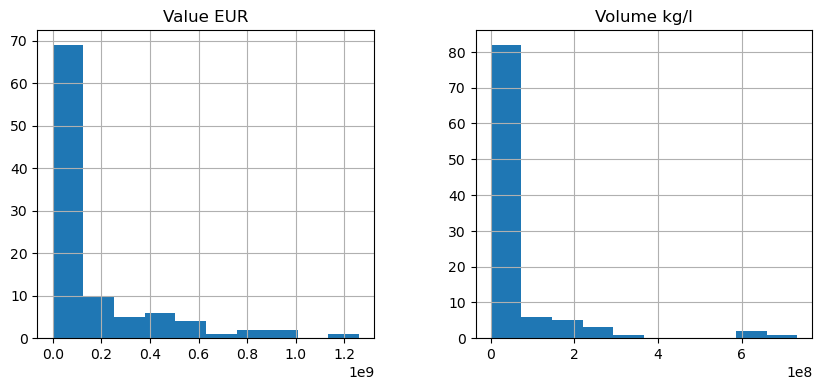

In [5]:
df[['Value EUR', 'Volume kg/l']].hist(figsize=(10, 4))

The histograms show that both sales value and sales volume are strongly right-skewed, with most observations concentrated at lower levels and only a small number of observations showing very large values. This indicates substantial variation across countries, years, and product categories. Since the dataset contains both value and volume information, the subsequent analysis examines whether higher sales volumes are associated with higher sales values, which would suggest a broadly positive value–volume relationship. Applying log transformation helps reduce the influence of extreme observations and makes the variables more suitable for regression analysis when testing this relationship.


array([[<Axes: title={'center': 'log_value'}>,
        <Axes: title={'center': 'log_volume'}>]], dtype=object)

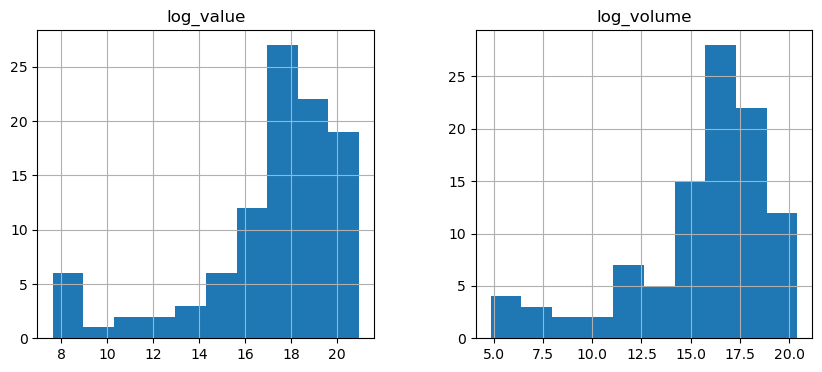

In [6]:
import numpy as np
df = add_sales_log_columns(df)
df[['log_value', 'log_volume']].hist(figsize=(10, 4))

After log transformation, the distributions of log_value and log_volume become less right-skewed compared with the original variables. The values are more spread out and less dominated by extreme observations, making them more suitable for correlation and OLS regression analysis.


In [7]:
import statsmodels.api as sm
X = sm.add_constant(df[['log_volume']])
model_log = fit_ols(df, ['log_volume'], 'log_value')
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:              log_value   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     2176.
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           1.01e-68
Time:                        13:24:29   Log-Likelihood:                -98.560
No. Observations:                 100   AIC:                             201.1
Df Residuals:                      98   BIC:                             206.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8911      0.290     13.424      0.0

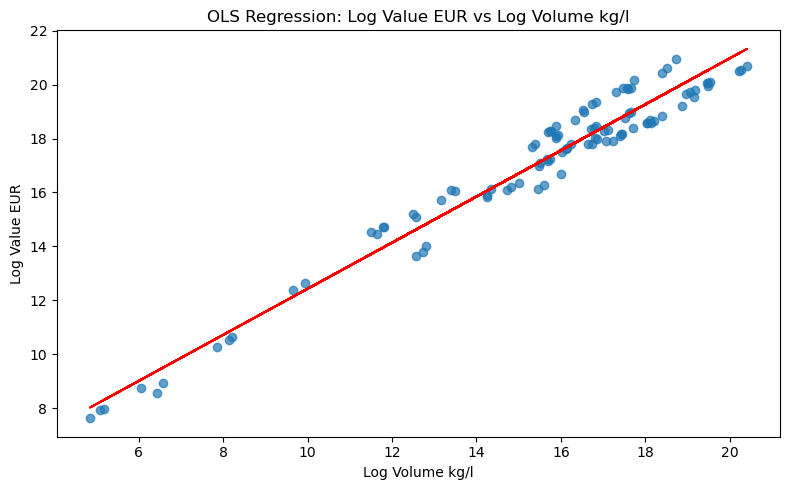

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(df['log_volume'], df['log_value'], alpha=0.7)
plt.plot(df['log_volume'], model_log.predict(X),color='red')
plt.title('OLS Regression: Log Value EUR vs Log Volume kg/l')
plt.xlabel('Log Volume kg/l')
plt.ylabel('Log Value EUR')
plt.tight_layout()
plt.show()

The log-log OLS regression shows a strong positive relationship between Volume kg/l and Value EUR. The model has a high R-squared value of 0.957, indicating that log volume explains most of the variation in log sales value. The coefficient of log_volume is positive and statistically significant, suggesting that higher sales volume is strongly associated with higher sales value. Therefore, since value and volume are highly correlated, the following analysis focuses on Value EUR as the main indicator and does not discuss Volume kg/l separately.


In [9]:
df_wide_value = create_wide_value_table(df)
df_wide_value.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,47756571.0,60439596.8,28291439.0,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,53453292.6,70771713.8,30617819.8,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,86449040.1,95499407.6,40249951.8,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,82826628.6,116339917.4,43862862.0,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,87256217.5,116808606.3,46100561.0,250165384.8


In [10]:
country_descriptive = df_wide_value.groupby(['Country'])[['Total Value EUR']].describe()
country_descriptive

Total Value EUR                                            \
                         count          mean           std           min   
Country                                                                    
Austria                    3.0  1.711763e+08  4.512949e+07  1.364876e+08   
Belgium                    3.0  2.599085e+08  2.332998e+07  2.430294e+08   
Denmark                    3.0  8.203163e+07  1.129062e+07  6.907380e+07   
France                     3.0  7.610923e+08  8.409217e+07  6.713733e+08   
Italy                      3.0  1.116265e+09  2.726988e+07  1.089518e+09   
Netherlands                3.0  6.583211e+08  1.444540e+08  5.350270e+08   
Romania                    3.0  2.283707e+07  5.585797e+06  1.858581e+07   
Spain                      3.0  1.029092e+09  1.821256e+08  8.491867e+08   
United Kingdom             3.0  1.334718e+09  3.848071e+08  1.000049e+09   

                                                                        
                         25%           50%           75%           max  
Country                                                                 
Austria         1.456652e+08  1.548428e+08  1.885206e+08  2.221984e+08  
Belgium         2.465974e+08  2.501654e+08  2.683481e+08  2.865308e+08  
Denmark         7.816988e+07  8.726596e+07  8.851055e+07  8.975514e+07  
France          7.225817e+08  7.737901e+08  8.059518e+08  8.381134e+08  
Italy           1.102383e+09  1.115248e+09  1.129639e+09  1.144029e+09  
Netherlands     5.788511e+08  6.226752e+08  7.199681e+08  8.172609e+08  
Romania         1.967389e+07  2.076197e+07  2.496271e+07  2.916344e+07  
Spain           9.369578e+08  1.024729e+09  1.119044e+09  1.213359e+09  
United Kingdom  1.124487e+09  1.248924e+09  1.502053e+09  1.755181e+09

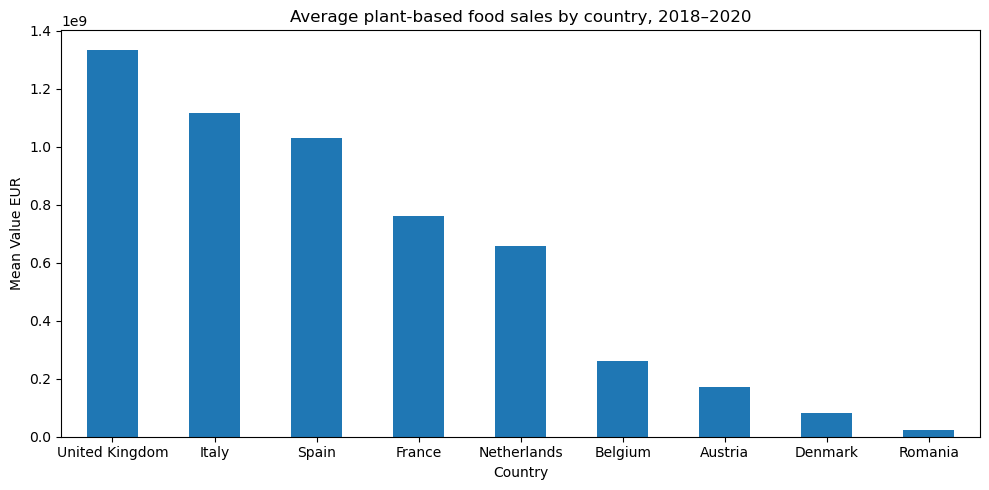

In [11]:
mean_value = country_descriptive[('Total Value EUR', 'mean')].sort_values(ascending=False)
mean_value.plot(kind='bar', figsize=(10, 5))
plt.title('Average plant-based food sales by country, 2018–2020')
plt.xlabel('Country')
plt.ylabel('Mean Value EUR')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The figure shows a clear concentration of plant-based food sales in a small number of markets from 2018 to 2020. The United Kingdom, Italy, and Spain accounted for the highest average sales values, suggesting that these countries had relatively larger and more developed plant-based food markets during this period. By contrast, countries such as Denmark and Romania showed much smaller sales values, indicating that market size differed substantially across Europe. This pattern suggests that plant-based food market development was uneven, with growth opportunities likely depending on country-specific market scale and consumer demand.


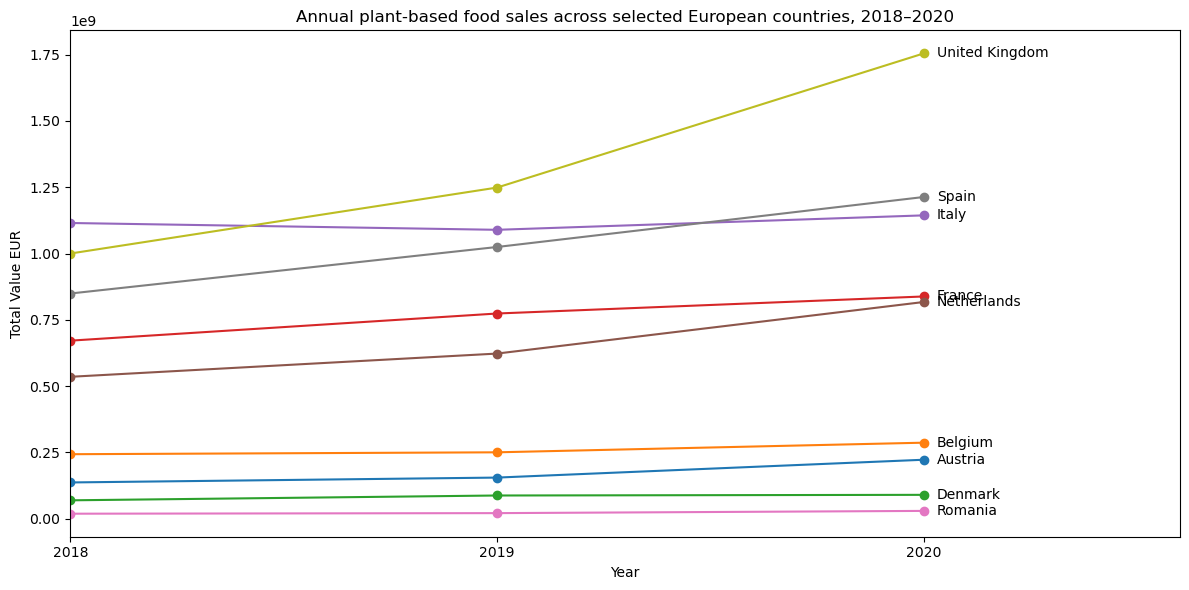

In [12]:
df_wide_value_wide = df_wide_value.pivot(
    index='Year',
    columns='Country',
    values='Total Value EUR')
ax = df_wide_value_wide.plot(
    figsize=(12, 6),
    marker='o',
    legend=False)
for country in df_wide_value_wide.columns:
    last_year = df_wide_value_wide.index[-1]
    last_value = df_wide_value_wide[country].iloc[-1]
    ax.text(last_year + 0.03, last_value, country, va='center')

plt.title('Annual plant-based food sales across selected European countries, 2018–2020')
plt.xlabel('Year')
plt.ylabel('Total Value EUR')
plt.xticks(df_wide_value_wide.index)
plt.xlim(df_wide_value_wide.index.min(), df_wide_value_wide.index.max() + 0.6)
plt.tight_layout()
plt.show()

Plant-based food sales increased in most selected European countries from 2018 to 2020, but the pace and scale of growth differed clearly across markets. The United Kingdom showed the strongest upward trend and became the leading market by 2020, while Spain and Italy remained consistently large markets. In contrast, countries such as Denmark and Romania stayed at much lower sales levels, suggesting that market expansion was uneven and mainly driven by a few major countries.


In [13]:
df_share, product_cols = create_share_table(df_wide_value)
df_share.head()

,Country,Year,Other plant-based foods / snacks & spreads,Plant-based cheese,Plant-based ice cream,Plant-based meat/fish alternatives & ready meals,Plant-based milk & drinks,Plant-based yogurt,Total Value EUR
0,Austria,2018.0,NaN,NaN,NaN,34.989676,44.282113,20.728211,136487606.8
1,Austria,2019.0,NaN,NaN,NaN,34.521000,45.705517,19.773483,154842826.2
2,Austria,2020.0,NaN,NaN,NaN,38.906239,42.979341,18.114420,222198399.5
3,Belgium,2018.0,NaN,NaN,NaN,34.080908,47.870716,18.048376,243029408.0
4,Belgium,2019.0,NaN,NaN,NaN,34.879413,46.692554,18.428034,250165384.8


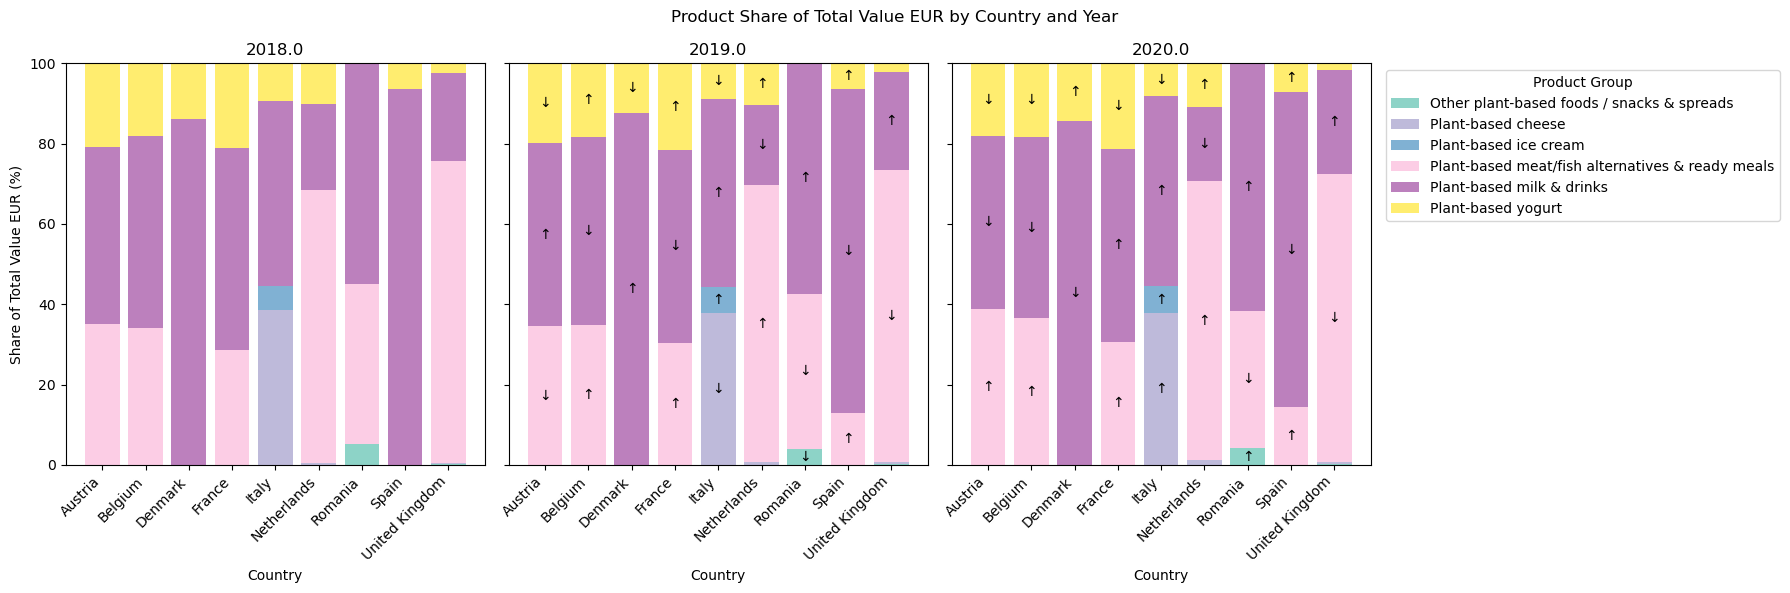

In [14]:
years = sorted(df_share['Year'].unique())
countries = sorted(df_share['Country'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(18, 6), sharey=True)
colors = plt.cm.Set3(np.linspace(0, 1, len(product_cols)))
for i, year in enumerate(years):
    ax = axes[i]
    data = (df_share[df_share['Year'] == year].set_index('Country').reindex(countries)[product_cols].fillna(0))
    bottom = np.zeros(len(countries))
    for j, product in enumerate(product_cols):
        values = data[product].values
        ax.bar(countries,values,bottom=bottom,label=product,color=colors[j])
        if i > 0:
            prev_year = years[i - 1]
            prev_data = (df_share[df_share['Year'] == prev_year].set_index('Country').reindex(countries)[product_cols].fillna(0))
            change = data[product].values - prev_data[product].values
            for x, value, base, diff in zip(range(len(countries)), values, bottom, change):
                if value > 3:
                    if diff > 0:
                        ax.text(x, base + value / 2, '↑', ha='center', va='center')
                    elif diff < 0:
                        ax.text(x, base + value / 2, '↓', ha='center', va='center')
        bottom += values
    ax.set_title(str(year))
    ax.set_xlabel('Country')
    ax.set_xticks(range(len(countries)))
    ax.set_xticklabels(countries, rotation=45, ha='right')
    ax.set_ylim(0, 100)
axes[0].set_ylabel('Share of Total Value EUR (%)')

plt.suptitle('Product Share of Total Value EUR by Country and Year')
plt.legend(title='Product Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


The figure shows that the contribution of different product categories to total plant-based food sales varied substantially across countries and years. Plant-based milk and drinks accounted for a large share in many countries, especially in Denmark, Spain, Austria, Belgium, and France, indicating that this category was a key driver of total sales. In contrast, plant-based meat/fish alternatives and ready meals represented a particularly large share in the United Kingdom and the Netherlands, suggesting that these markets were more strongly shaped by meat-alternative products. The arrows show that category shares changed over time, but the overall market structure remained relatively stable in several countries. This suggests that plant-based food markets were not homogeneous across Europe; instead, each country appeared to have a different product-category profile, which may reflect differences in consumer preferences and market development pathways.


Cleaned YouTube Narrative Data

The following section directly uses the cleaned aspect-coded CSV in `data/Clean`. The CSV contains positive and negative source columns for each narrative dimension, but this notebook combines each pair for analysis. For example, `health` equals 1 when either `health_positive` or `health_negative` is 1. This avoids double-counting videos that mention both positive and negative evaluations of the same dimension.

Because the sales dataset covers 2018-2020, the YouTube data is filtered to the same period before the sales relationship and OLS regression analysis.


In [15]:
youtube_path = Path("../data/Clean/ALL_11countries_2017_2020_aspect_sentiment.csv")
df_youtube_all = pd.read_csv(youtube_path, encoding="utf-8-sig")

narrative_cols = [
    "health",
    "environment",
    "animal_welfare",
    "food_security",
    "taste",
    "price",
    "convenience",
]
sentiment_source_cols = [f"{narrative}_{sentiment}" for narrative in narrative_cols for sentiment in ["positive", "negative"]]

def format_narrative_label(column):
    return column.replace("_", " ").title()

narrative_meta = pd.DataFrame({
    "narrative": narrative_cols,
    "positive_source_column": [f"{col}_positive" for col in narrative_cols],
    "negative_source_column": [f"{col}_negative" for col in narrative_cols],
})
narrative_meta["label"] = narrative_meta["narrative"].apply(format_narrative_label)

df_youtube = df_youtube_all.copy()
df_youtube["Year"] = pd.to_numeric(df_youtube["year"], errors="coerce").astype("Int64")
df_youtube["Country"] = df_youtube["country"].astype(str).str.strip()
df_youtube[sentiment_source_cols] = (
    df_youtube[sentiment_source_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .astype(int)
)
for narrative in narrative_cols:
    source_cols = [f"{narrative}_positive", f"{narrative}_negative"]
    df_youtube[narrative] = df_youtube[source_cols].max(axis=1).astype(int)

df_youtube["view_count_numeric"] = pd.to_numeric(df_youtube.get("view_count"), errors="coerce").fillna(0)
df_youtube_1820 = df_youtube[df_youtube["Year"].between(2018, 2020)].copy()

print("Loaded cleaned YouTube data from:", youtube_path)
print("All YouTube rows:", len(df_youtube_all))
print("YouTube rows used for 2018-2020 analysis:", len(df_youtube_1820))
print("Videos by year:")
print(df_youtube_1820["Year"].value_counts().sort_index())
print("Countries:", sorted(df_youtube_1820["Country"].dropna().unique()))
display(narrative_meta)
display(df_youtube_1820[["Country", "Year", "title"] + narrative_cols].head())


Loaded cleaned YouTube data from: ..\data\Clean\ALL_11countries_2017_2020_aspect_sentiment.csv
All YouTube rows: 4170
YouTube rows used for 2018-2020 analysis: 3209
Videos by year:
Year
2018    1030
2019    1079
2020    1100
Name: count, dtype: Int64
Countries: ['Austria', 'Belgium', 'Denmark', 'France', 'Germany', 'Italy', 'Netherlands', 'Poland', 'Romania', 'Spain', 'United Kingdom']


,narrative,positive_source_column,negative_source_column,label
0,health,health_positive,health_negative,Health
1,environment,environment_positive,environment_negative,Environment
2,animal_welfare,animal_welfare_positive,animal_welfare_negative,Animal Welfare
3,food_security,food_security_positive,food_security_negative,Food Security
4,taste,taste_positive,taste_negative,Taste
5,price,price_positive,price_negative,Price
6,convenience,convenience_positive,convenience_negative,Convenience


,Country,Year,title,health,environment,animal_welfare,food_security,taste,price,convenience
100,Austria,2018,How To Make a Vegan Curry,0,0,0,0,1,0,0
101,Austria,2018,How To Make a Vegan Lasagna,0,0,0,0,1,0,0
102,Austria,2018,$10 Vegan vs. $135 Vegan,0,0,0,0,1,0,0
103,Austria,2018,We Tried The 7-Day Vegan Challenge • Mom In Pr...,1,0,0,0,0,0,0
104,Austria,2018,Vegans Vs. Meat Eaters: What Is The Right Diet...,0,0,0,0,0,0,0


In [16]:
example_rows = []
for narrative in narrative_cols:
    examples = (
        df_youtube_1820[df_youtube_1820[narrative].eq(1)]
        .sort_values("view_count_numeric", ascending=False)
        .head(3)
    )
    for _, row in examples.iterrows():
        example_rows.append({
            "narrative": format_narrative_label(narrative),
            "country": row["Country"],
            "year": int(row["Year"]),
            "title": row["title"],
            "url": row.get("url", ""),
            "view_count": int(row["view_count_numeric"]),
        })

example_videos = pd.DataFrame(example_rows)
display(example_videos)


,narrative,country,year,title,url,view_count
0,Health,Romania,2018,Yes Yes Vegetables Song | @CoComelon Nursery R...,https://www.youtube.com/watch?v=ohHYABXMqUQ,3433949140
1,Health,Spain,2018,Yes Yes Vegetables Song | @CoComelon Nursery R...,https://www.youtube.com/watch?v=ohHYABXMqUQ,3433949140
2,Health,Spain,2019,Aprenda los Vegetales para Niños con Blippi Es...,https://www.youtube.com/watch?v=Rd4Fznng8qw,112256626
3,Environment,United Kingdom,2020,Which type of milk is best for you? - Jonathan...,https://www.youtube.com/watch?v=s6TXDFp1EcM,6195292
4,Environment,France,2018,Baked Banana Oatmeal Muffin Cups | Healthy + E...,https://www.youtube.com/watch?v=X4qJZsgae2M,5375332
5,Environment,United Kingdom,2018,"Debt-Free Family Life in a Zero Waste, Plant B...",https://www.youtube.com/watch?v=higZGd1fU4Q,3937075
6,Animal Welfare,Austria,2018,Die Wahrheit über Veganismus - 30 Tage Vegan S...,https://www.youtube.com/watch?v=2Qk75XhDFJk,2652932
7,Animal Welfare,France,2018,Die Wahrheit über Veganismus - 30 Tage Vegan S...,https://www.youtube.com/watch?v=2Qk75XhDFJk,2652932
8,Animal Welfare,United Kingdom,2018,Die Wahrheit über Veganismus - 30 Tage Vegan S...,https://www.youtube.com/watch?v=2Qk75XhDFJk,2652932
9,Food Security,United Kingdom,2019,Lentils: A Miracle Of Nutrition [Full Document...,https://www.youtube.com/watch?v=1zzA9XA67ew,3032957


The example table is used as a content check for the combined narrative categories. Each category now includes both positive and negative mentions, so the table should be interpreted as showing videos that discuss a topic, not videos that necessarily evaluate it positively. For example, the health category includes both health benefits and health risks.

In [17]:
narrative_by_year = df_youtube_1820.groupby("Year")[narrative_cols].sum()
narrative_rate_by_year = df_youtube_1820.groupby("Year")[narrative_cols].mean().mul(100)
narrative_totals = df_youtube_1820[narrative_cols].sum().sort_values(ascending=False)
narrative_rate_by_country = df_youtube_1820.groupby("Country")[narrative_cols].mean().mul(100)

display(narrative_totals.rename("mentioned_videos").to_frame())
display(narrative_by_year)


,mentioned_videos
health,869
taste,657
convenience,549
environment,100
price,81
animal_welfare,54
food_security,10


,health,environment,animal_welfare,food_security,taste,price,convenience
Year,,,,,,,
2018,271,49,20,6,192,19,147
2019,300,31,15,3,248,26,181
2020,298,20,19,1,217,36,221


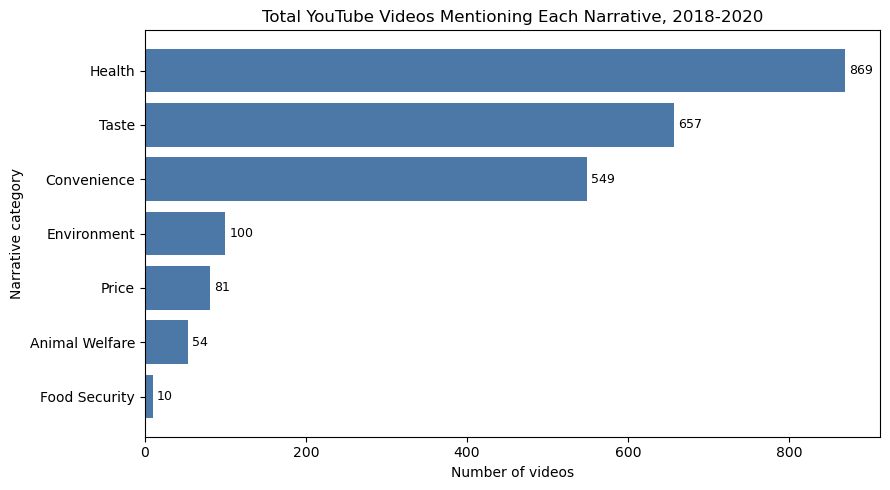

In [18]:
plot_totals = narrative_totals.sort_values()
plot_labels = [format_narrative_label(col) for col in plot_totals.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_labels, plot_totals.values, color="#4C78A8")
ax.set_title("Total YouTube Videos Mentioning Each Narrative, 2018-2020")
ax.set_xlabel("Number of videos")
ax.set_ylabel("Narrative category")
for i, value in enumerate(plot_totals.values):
    ax.text(value + 5, i, f"{int(value)}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


After combining positive and negative mentions, health is the most frequent narrative, followed by taste and convenience. Environment, price, animal welfare, and food security appear much less often. This suggests that YouTube discussion of plant-based foods is mainly organized around personal health, eating experience, and practical use, while broader ethical or system-level narratives are less visible in the title and description text.

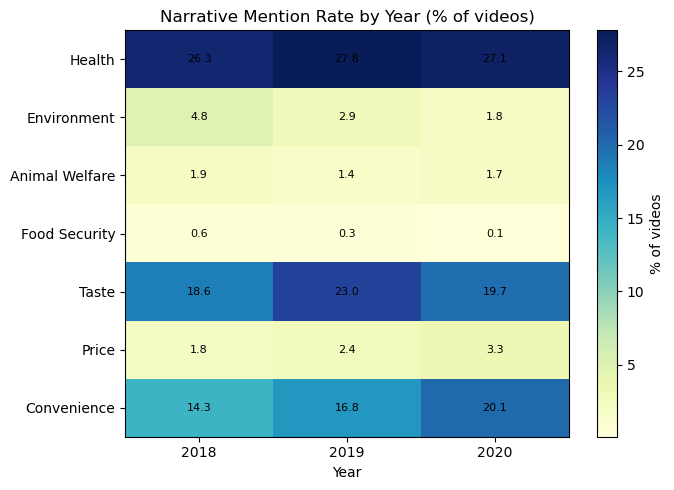

In [19]:
heatmap_year = narrative_rate_by_year[narrative_cols].T
heatmap_labels = [format_narrative_label(col) for col in heatmap_year.index]

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(heatmap_year.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(heatmap_year.columns)))
ax.set_xticklabels(heatmap_year.columns.astype(int))
ax.set_yticks(range(len(heatmap_labels)))
ax.set_yticklabels(heatmap_labels)
ax.set_xlabel("Year")
ax.set_title("Narrative Mention Rate by Year (% of videos)")

for row_i in range(heatmap_year.shape[0]):
    for col_i in range(heatmap_year.shape[1]):
        value = heatmap_year.iloc[row_i, col_i]
        ax.text(col_i, row_i, f"{value:.1f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="% of videos")
plt.tight_layout()
plt.show()


The yearly heatmap shows that health remains the most common narrative in every year, appearing in roughly one quarter of videos. Taste is also consistently visible, while convenience increases from 2018 to 2020. Environment declines over time in this dataset, and food security remains rare. These patterns suggest that the most stable YouTube narratives are consumer-facing topics rather than abstract system-level topics.

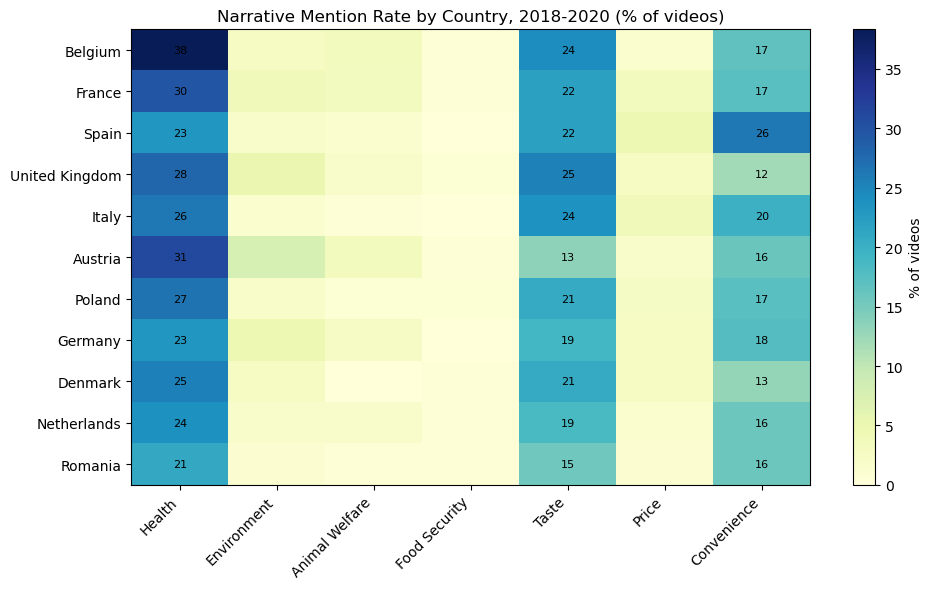

In [20]:
country_order = narrative_rate_by_country.mean(axis=1).sort_values(ascending=False).index
heatmap_country = narrative_rate_by_country.loc[country_order, narrative_cols]
country_labels = heatmap_country.index.tolist()
column_labels = [format_narrative_label(col) for col in heatmap_country.columns]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_country.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(column_labels)))
ax.set_xticklabels(column_labels, rotation=45, ha="right")
ax.set_yticks(range(len(country_labels)))
ax.set_yticklabels(country_labels)
ax.set_title("Narrative Mention Rate by Country, 2018-2020 (% of videos)")

for row_i in range(heatmap_country.shape[0]):
    for col_i in range(heatmap_country.shape[1]):
        value = heatmap_country.iloc[row_i, col_i]
        if value >= 10:
            ax.text(col_i, row_i, f"{value:.0f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="% of videos")
plt.tight_layout()
plt.show()


The country heatmap shows that health, taste, and convenience are the main narrative dimensions across most countries, but the emphasis differs by market. Some countries show stronger health framing, while others show more taste or convenience framing. This suggests that plant-based food communication is broadly similar across countries, but local markets differ in which consumer-facing narrative receives more attention.

In [21]:
sales_path = Path("../data/Clean/plant_based_food_sales_data.csv")
sales_raw_for_merge = pd.read_csv(sales_path)

sales_country_year = sales_raw_for_merge[["Country", "Year", "Value EUR"]].copy()
sales_country_year["Year"] = pd.to_numeric(sales_country_year["Year"], errors="coerce").astype("Int64")
sales_country_year["Value EUR"] = pd.to_numeric(sales_country_year["Value EUR"], errors="coerce").fillna(0)
sales_country_year = sales_country_year.dropna(subset=["Country", "Year"])
sales_country_year = sales_country_year[sales_country_year["Value EUR"] != 0]
sales_country_year = (
    sales_country_year
    .groupby(["Country", "Year"], as_index=False)["Value EUR"]
    .sum()
    .rename(columns={"Value EUR": "Total Value EUR"})
)
sales_country_year["Year"] = sales_country_year["Year"].astype(int)

narrative_country_year = (
    df_youtube_1820
    .groupby(["Country", "Year"])
    .agg(video_count=("video_id", "count"), **{col: (col, "sum") for col in narrative_cols})
    .reset_index()
)
narrative_country_year["Year"] = narrative_country_year["Year"].astype(int)
for col in narrative_cols:
    narrative_country_year[f"{col}_rate"] = narrative_country_year[col] / narrative_country_year["video_count"]

missing_sales_country_year = (
    narrative_country_year[["Country", "Year"]]
    .merge(sales_country_year[["Country", "Year"]], on=["Country", "Year"], how="left", indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns="_merge")
)

narrative_sales_country_year = narrative_country_year.merge(
    sales_country_year,
    on=["Country", "Year"],
    how="inner",
)
narrative_sales_country_year["log_total_value"] = np.log(narrative_sales_country_year["Total Value EUR"])

print("Country-year observations in YouTube data:", len(narrative_country_year))
print("Country-year observations used in sales relationship analysis:", len(narrative_sales_country_year))
print("Country-year observations without usable sales value:")
display(missing_sales_country_year)
display(narrative_sales_country_year.head())


Country-year observations in YouTube data: 33
Country-year observations used in sales relationship analysis: 30
Country-year observations without usable sales value:


,Country,Year
12,Germany,2018
13,Germany,2019
14,Germany,2020


,Country,Year,video_count,health,environment,animal_welfare,food_security,taste,price,convenience,health_rate,environment_rate,animal_welfare_rate,food_security_rate,taste_rate,price_rate,convenience_rate,Total Value EUR,log_total_value
0,Austria,2018,100,32,12,2,1,16,2,11,0.32,0.12,0.02,0.01,0.16,0.02,0.11,136487606.8,18.731744
1,Austria,2019,100,30,6,6,0,17,1,22,0.30,0.06,0.06,0.00,0.17,0.01,0.22,154842826.2,18.857921
2,Austria,2020,100,31,5,2,0,7,2,15,0.31,0.05,0.02,0.00,0.07,0.02,0.15,222198399.5,19.219081
3,Belgium,2018,100,42,6,6,1,19,1,12,0.42,0.06,0.06,0.01,0.19,0.01,0.12,243029408.0,19.308693
4,Belgium,2019,100,37,0,1,0,28,1,20,0.37,0.00,0.01,0.00,0.28,0.01,0.20,250165384.8,19.337633


For the sales relationship analysis, YouTube narratives are aggregated to the country-year level and merged with total sales value. This keeps the sales analysis aligned with the 2018-2020 period. The merge uses non-zero `Value EUR`; therefore Germany is listed as unmatched because the clean sales file does not contain usable non-zero sales value for Germany in these years. The YouTube-only narrative charts above still include Germany.

,label,corr_with_log_total_value
5,Price,0.465412
4,Taste,0.426797
6,Convenience,0.247845
2,Animal Welfare,0.202747
0,Health,0.130492
1,Environment,0.003183
3,Food Security,-0.190355


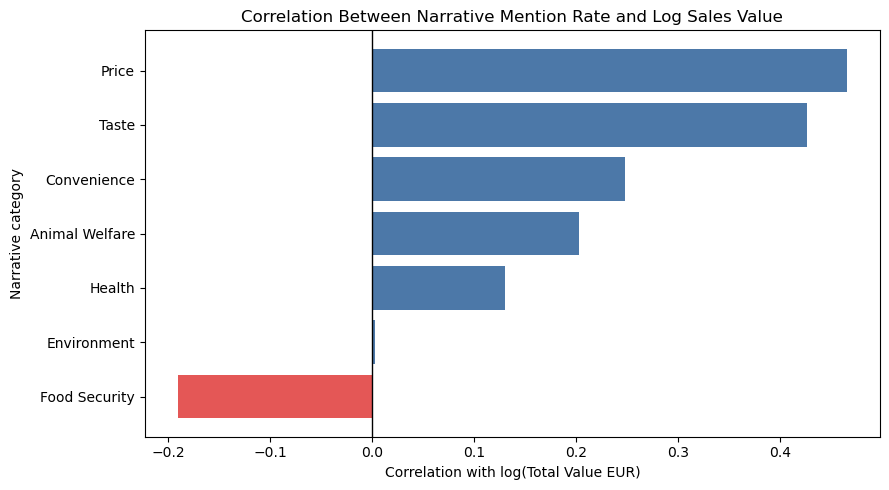

In [22]:
rate_cols = [f"{col}_rate" for col in narrative_cols]

corr_table = pd.DataFrame({
    "narrative": narrative_cols,
    "corr_with_log_total_value": [
        narrative_sales_country_year[f"{col}_rate"].corr(narrative_sales_country_year["log_total_value"])
        for col in narrative_cols
    ],
})
corr_table = corr_table.merge(narrative_meta[["narrative", "label"]], on="narrative", how="left")
corr_table = corr_table.sort_values("corr_with_log_total_value", ascending=False)
display(corr_table[["label", "corr_with_log_total_value"]])

plot_corr = corr_table.sort_values("corr_with_log_total_value")
colors = ["#4C78A8" if value >= 0 else "#E45756" for value in plot_corr["corr_with_log_total_value"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_corr["label"], plot_corr["corr_with_log_total_value"], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Correlation Between Narrative Mention Rate and Log Sales Value")
ax.set_xlabel("Correlation with log(Total Value EUR)")
ax.set_ylabel("Narrative category")
plt.tight_layout()
plt.show()


The correlation chart is useful as an exploratory first look, but it does not control for overlap between narratives. Therefore, the final analysis uses OLS regression, following the method introduced in class. Before fitting the OLS model, the next heatmap checks how strongly the seven narrative variables are correlated with each other.

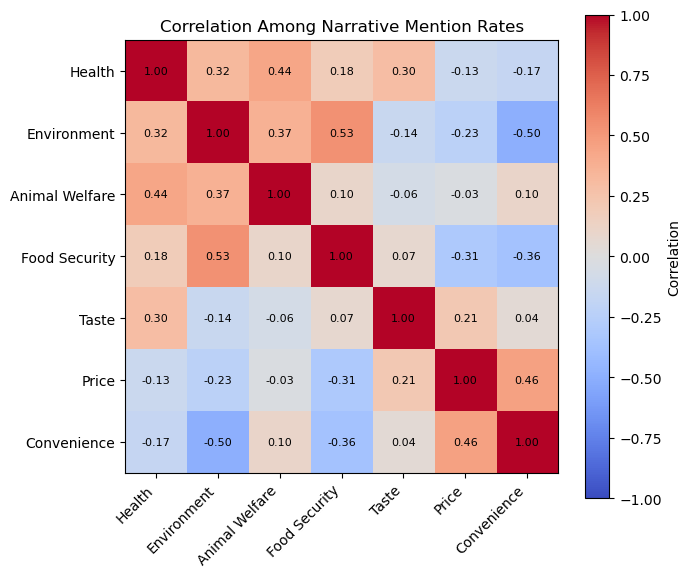

In [23]:
rate_corr = narrative_sales_country_year[rate_cols].corr()
rate_corr.index = [format_narrative_label(col.replace("_rate", "")) for col in rate_corr.index]
rate_corr.columns = [format_narrative_label(col.replace("_rate", "")) for col in rate_corr.columns]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(rate_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(rate_corr.columns)))
ax.set_xticklabels(rate_corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(rate_corr.index)))
ax.set_yticklabels(rate_corr.index)
ax.set_title("Correlation Among Narrative Mention Rates")

for row_i in range(rate_corr.shape[0]):
    for col_i in range(rate_corr.shape[1]):
        value = rate_corr.iloc[row_i, col_i]
        ax.text(col_i, row_i, f"{value:.2f}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.show()


The heatmap shows whether the seven narrative rates tend to appear together in the same country-year contexts. This matters for OLS interpretation because a coefficient estimates the association of one narrative while holding the other included narratives constant. If two narrative variables overlap strongly, their individual coefficients may become less stable.

In [24]:
# OLS regression: combined narrative mention rates and plant-based food sales
# The dependent variable is log(Total Value EUR).
# Each explanatory variable is the share of videos in a country-year that mention a narrative dimension.

regression_data = narrative_sales_country_year[
    ["Country", "Year", "Total Value EUR", "log_total_value", "video_count"] + rate_cols
].dropna().copy()

combined_narrative_ols_model = fit_ols(regression_data, rate_cols, "log_total_value")

ols_model_summary = pd.DataFrame([{
    "model": "Combined 7-narrative OLS",
    "n_observations": int(combined_narrative_ols_model.nobs),
    "n_predictors": len(rate_cols),
    "r_squared": combined_narrative_ols_model.rsquared,
    "adjusted_r_squared": combined_narrative_ols_model.rsquared_adj,
    "f_pvalue": combined_narrative_ols_model.f_pvalue,
}])
display(ols_model_summary)

conf_int = combined_narrative_ols_model.conf_int().loc[rate_cols]
ols_coefficients = pd.DataFrame({
    "variable": rate_cols,
    "coefficient": combined_narrative_ols_model.params.loc[rate_cols],
    "p_value": combined_narrative_ols_model.pvalues.loc[rate_cols],
    "conf_low": conf_int[0],
    "conf_high": conf_int[1],
}).reset_index(drop=True)
ols_coefficients["narrative"] = ols_coefficients["variable"].str.replace("_rate", "", regex=False)
ols_coefficients["label"] = ols_coefficients["narrative"].apply(format_narrative_label)
ols_coefficients["coefficient_per_10pp_increase"] = ols_coefficients["coefficient"] * 0.10
ols_coefficients["conf_low_per_10pp"] = ols_coefficients["conf_low"] * 0.10
ols_coefficients["conf_high_per_10pp"] = ols_coefficients["conf_high"] * 0.10

display(ols_coefficients[[
    "label",
    "coefficient_per_10pp_increase",
    "p_value",
    "conf_low_per_10pp",
    "conf_high_per_10pp",
]].sort_values("coefficient_per_10pp_increase", ascending=False))

print("Combined 7-narrative OLS summary")
print(combined_narrative_ols_model.summary())


,model,n_observations,n_predictors,r_squared,adjusted_r_squared,f_pvalue
0,Combined 7-narrative OLS,30,7,0.432994,0.252583,0.055033


,label,coefficient_per_10pp_increase,p_value,conf_low_per_10pp,conf_high_per_10pp
5,Price,2.432783,0.130451,-0.778697,5.644263
2,Animal Welfare,1.380364,0.400244,-1.956841,4.717568
1,Environment,1.234329,0.277080,-1.062460,3.531118
4,Taste,1.025681,0.027178,0.126840,1.924522
6,Convenience,0.257772,0.620624,-0.807046,1.322590
0,Health,-0.147732,0.755649,-1.120029,0.824565
3,Food Security,-6.252184,0.249259,-17.208421,4.704053


Combined 7-narrative OLS summary
                            OLS Regression Results                            
Dep. Variable:        log_total_value   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     2.400
Date:                Fri, 26 Jun 2026   Prob (F-statistic):             0.0550
Time:                        13:24:32   Log-Likelihood:                -41.690
No. Observations:                  30   AIC:                             99.38
Df Residuals:                      22   BIC:                             110.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
c

The OLS model estimates the association between the seven combined narrative mention rates and log sales value at the country-year level. Each coefficient shows the expected change in log sales value when a narrative's mention rate increases by 10 percentage points, holding the other six narrative rates constant. This regression goes beyond simple correlation because it controls for overlap between narrative dimensions. However, the results should still be interpreted as exploratory associations rather than causal effects because the sample is small and country-level market differences may also matter.

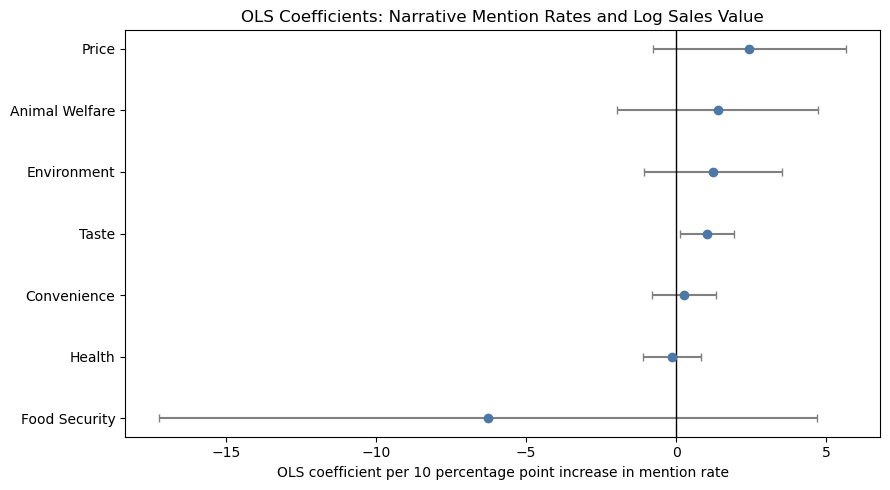

In [25]:
plot_coefficients = ols_coefficients.sort_values("coefficient_per_10pp_increase")
y_positions = np.arange(len(plot_coefficients))
lower_error = plot_coefficients["coefficient_per_10pp_increase"] - plot_coefficients["conf_low_per_10pp"]
upper_error = plot_coefficients["conf_high_per_10pp"] - plot_coefficients["coefficient_per_10pp_increase"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    plot_coefficients["coefficient_per_10pp_increase"],
    y_positions,
    xerr=[lower_error, upper_error],
    fmt="o",
    color="#4C78A8",
    ecolor="gray",
    capsize=3,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(y_positions)
ax.set_yticklabels(plot_coefficients["label"])
ax.set_xlabel("OLS coefficient per 10 percentage point increase in mention rate")
ax.set_title("OLS Coefficients: Narrative Mention Rates and Log Sales Value")
plt.tight_layout()
plt.show()


The coefficient plot visualizes the OLS regression results for the seven combined narratives. Points to the right of zero indicate narratives that are positively associated with log sales value after controlling for the other narratives; points to the left indicate negative associations. Wide confidence intervals would indicate uncertainty, so the direction, size, and statistical significance of each coefficient should be discussed together rather than relying only on the visual position of the point.